# Quantum support vector machine

In this notebook, we will explore a quantum algorithm developped to enhance a machine learning (ML) algorithm. In particular, we will study the Quantum enhanced support vector machine, introduced by the scientific staff of IBM in Ref.[1](https://arxiv.org/pdf/1804.11326.pdf).

## Brief overview of kernels

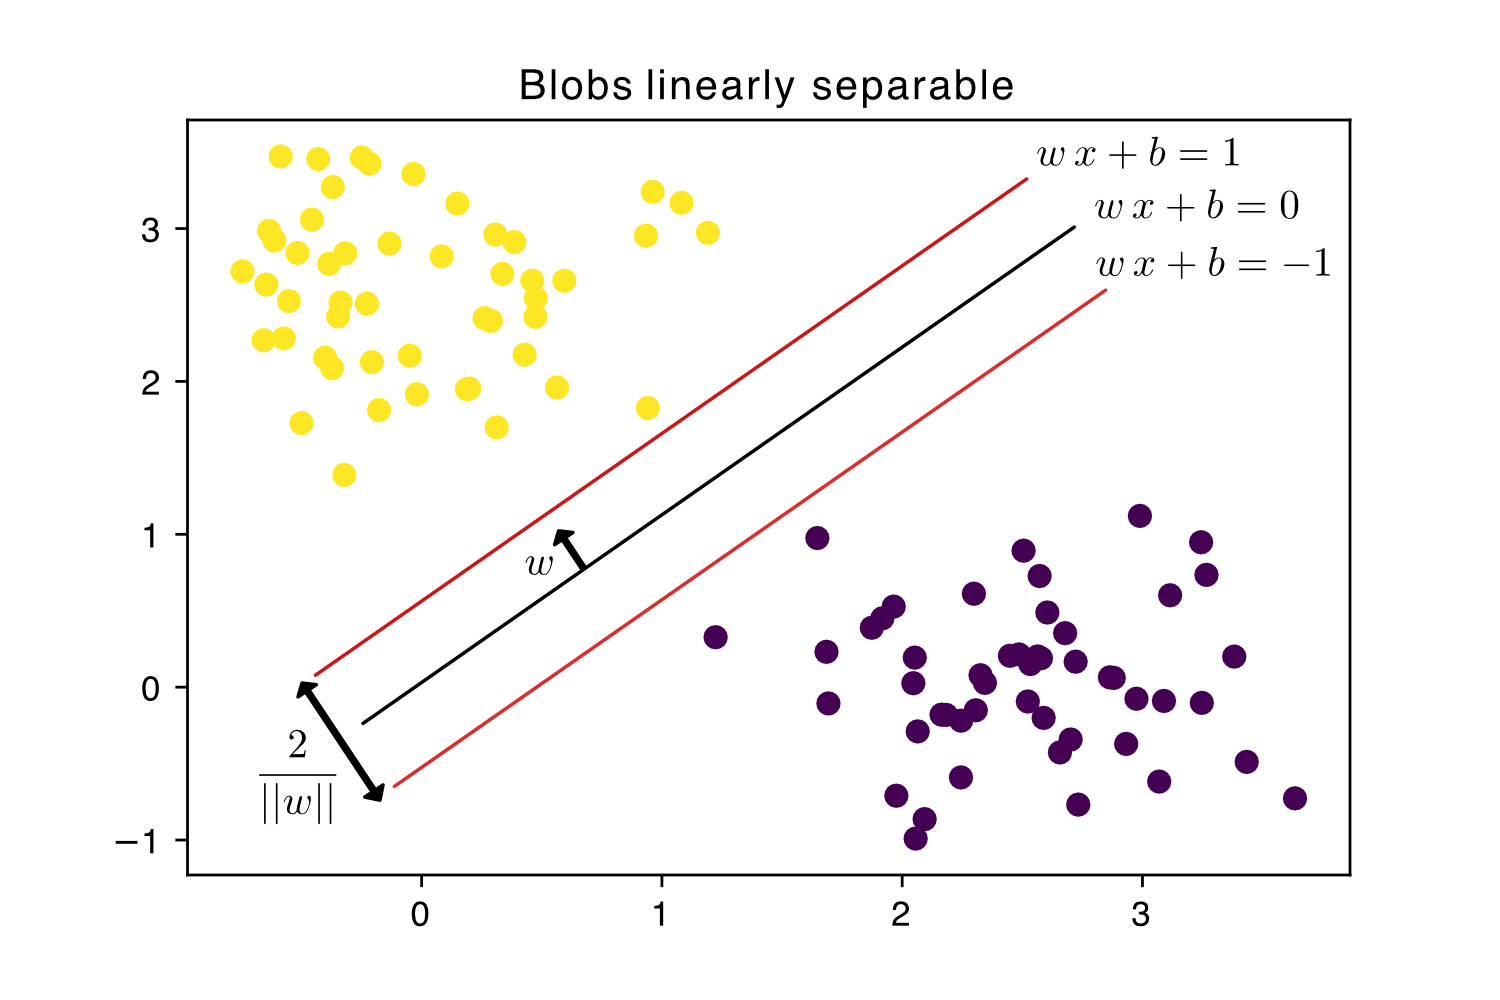

The support vector machine algorithm tries to find the parameters $w$ and $b$ such that the data with labels $y=1$ satisfy $w\,x+b>1$, and the data $y=-1$ satisfy $w\,x+b<1$. The optimization problem therefore consists in maximizing the distance between the two hyperplanes $\frac{2}{\vert \vert w \vert \vert}$ (or minimizing $\vert \vert w \vert \vert^2$) given the constraints $y_i (w\,x+b)>1$. This problem corresponds to the optimization of a quadratic problem with linear constraints 

$\min \limits_{w,b}\vert \vert w\vert \vert^2 \text{ such that } y_i (w \, x_i+b)\geq 1, i=1...N$

and has therefore a unique extremum. The latter can be found with a gradient-descent technique.

In some of the problems, one would prefer to have a control on the margins by giving a weight to every point of the dataset, which would be an hyper parameter. This can done by considering the following problem

$\min \limits_{w,b,\xi_i>0}\vert \vert w\vert \vert^2+C\sum_{i=1}^{N}\xi_i \text{ such that } y_i (w x_i+b)\geq 1-\xi_i, i=1...N$

For $C=\infty$, we recover the hard margin case. The value of C allows one to control the size of the margins.

Combining the inequalities $\xi\geq 0$ and $y_i (w x_i+b)\geq 1-\xi_i$, the minization problem can be rewritten as

$\min \limits_{w,b,\xi_i>0}\vert \vert w\vert \vert^2+C\sum_{i=1}^{N}\max(0,1-y_i (w x_i+b))$

The second term of this inequality is the so called Hinge Loss and the SVM problem can be seen as a minization of the Hing Loss with a $L_2$ regularization of the weigths. We finally notice that problem has still a unique minimum.

One can show that the optimization problem of the SVM is equivalent to the minization its dual formulation. For example, in the case of the soft margins, the dual problem takes the form

$\max \limits_{\{\alpha_i\}}\sum_i-\frac{1}{2}\sum_{j,k}\alpha_j\alpha_k y_j y_k (x_j^Tx_k) \text{ with the constraints } 0 \leq \alpha_i \leq C \text{ and } \sum_i \alpha_i y_i=0$

One of the advantages of this formulation is that oit only involves the saclar products $ x_j^T x_k$. This is a crucial point when we will go to kernel methods. 

## Support vector machine with Kernel

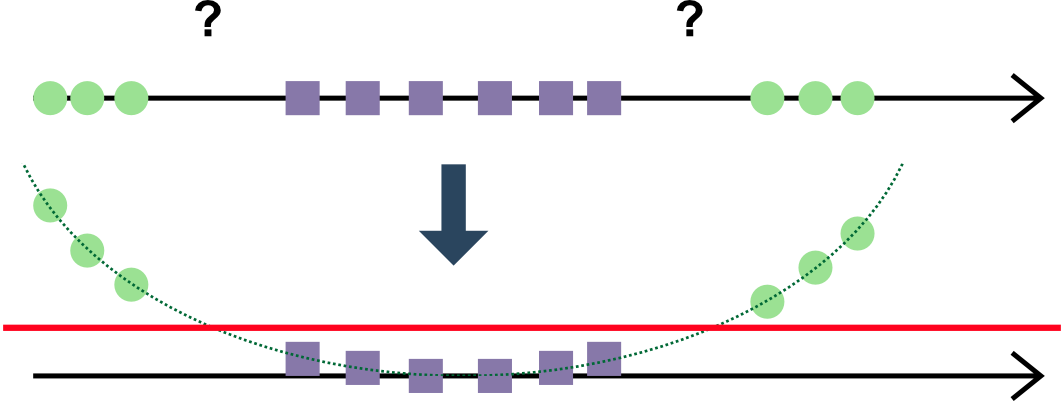

As we have already seen, the data are not always linearly separable. A simple trick to be able to still use a linear classifier are the kernel methods, as sketched in the Figure above. For example, this one-dimensional dataset is not linearly separable. However, when embedding them in the two-dimensional space with the map $\Phi: x \rightarrow (x,x^2)$. The datas become again linearly separable. In the ducal formulation, one only has to compute the scalar product $ x_j^T x_k$, which after the embedding takes the form $ \Phi(x_j^T) \Phi(x_k)$. The pretty nice point of using the kernel trick is that one does not have to do the embedding if one knows the value of the the scalar product. An example is the gaussian kernels where the data are embedded in a high dimensional space and mapped to gaussians, where the scalar product can be computed analitcally. 

Support Vector Classification (SVC) is a powerful and versatile supervised machine learning algorithm. It works by finding the optimal hyperplane that maximally separates data points of different classes in the feature space, thereby ensuring the best generalization to new data. This hyperplane is determined using support vectors, which are the data points closest to the decision boundary and are critical in defining the hyperplane's position and orientation. 

kernel functions are used to map the input data into a higher-dimensional space where a linear hyperplane can be used to separate the classes. The decision function in this case involves the kernel function $K(x_{i},x_{j})$:

\begin{equation}
    f(x) = sign \left(\sum_{i} y_{i}\alpha_{i}K(x_{i},x_{j})+b\right)
\end{equation}

where:

$\alpha $ are the Lagrange multipliers obtained during training.

$ y_i$ are the class labels of the support vectors.

$x_i$ are the support vectors.

$K(x_{i},x_{j})$ is the kernel function that computes the dot product in the transformed feature space.

$b$ is the bias term.

In [11]:
import numpy as np

In [12]:
train = np.load('train.npz')
print(train.files)

['train_features', 'train_labels']


In [13]:
X_train = train['train_features']
y_train = train['train_labels']

In [14]:
test = np.load('test.npz')
print(test.files)

['test_features', 'test_labels']


In [15]:
X_test = test['test_features']
y_test = test['test_labels']

## Classical Support Vector Classifier
Now, as we have load the dataset, let us do a classification using svc. For this, we will use scikit-learn or sklearn. Scikit-learn, also known as sklearn, is an open-source machine learning library for Python. It provides simple and efficient tools for data analysis and modeling. Built on libraries like NumPy, SciPy, and Matplotlib, it offers a wide range of algorithms for tasks such as classification, regression, clustering, and dimensionality reduction.


In [6]:
from sklearn.svm import SVC
svm_model = SVC() # loading the classifier
svm_model.fit(X_train, y_train) # train the classifier

SVC()

In [7]:
predictions = svm_model.predict(X_test) # testing the model

In [8]:
from sklearn.metrics import roc_curve,roc_auc_score,confusion_matrix,accuracy_score,precision_score
from sklearn.metrics import recall_score,f1_score,classification_report

In [9]:
report = classification_report(y_test,predictions)
print(report)

              precision    recall  f1-score   support

         0.0       0.77      0.90      0.83       107
         1.0       0.79      0.59      0.68        71

    accuracy                           0.78       178
   macro avg       0.78      0.74      0.75       178
weighted avg       0.78      0.78      0.77       178



# Quantum Support Vector Classifier

Let us compare the classical SVC with quantum SVC

Quantum support vector machine represents a quantum-classical hybrid approach where kernel value is computed using a quantum computer and the classification process is performed on a classical machine. For computing the kernel values, classical data must be converted into quantum states. Therefore, first the classical data points are transformed to quantum states using feature mapping techniques and then the kernel values are estimated.

In [10]:
# Importing standard Qiskit libraries
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZFeatureMap, ZZFeatureMap
from qiskit.quantum_info import Statevector
from qiskit.circuit import ParameterVector
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel, FidelityStatevectorKernel
from qiskit_machine_learning.algorithms import QSVC

Here, ZFeatureMap, ZZFeatureMap are predefind angle embedding circuits. A Sampler Primitive calculates probabilities of bitstrings from quantum circuits. You can read about different type of preimitives here- https://medium.com/qiskit/what-are-qiskit-primitives-9bf63c1eacc7 .
ComputeUncompute along with FidelityQuantumKernel, FidelityStatevectorKernel used to compute inner product or fidelity.-, which is-

\begin{equation}
K(x_{i},x_{j}) = |{\langle{\psi_{x_i}} |{\psi_{x_j}}}\rangle|^2 = 
|{\langle{0^n}|\mathcal{U}^{\dagger}_{\psi(x_i)}\mathcal{U}_{\psi({x_j})}|{0^n}\rangle}|^2.
\end{equation}

where $K(x_{i},x_{j})$ is a kernel value calculated between two points(vectors) $x_i$ and $x_j$. On the other around it can also be thought of as caculating distance between two points. Then this kernel value is passed into classical SVC to compute the class or to do the classification.

\begin{equation}
    class = sign \left(\sum_{i} y_{i}\alpha_{i}K(x_{i},x_{j})+b\right)
\end{equation}

In [11]:
import matplotlib.pyplot as plt

# Angle Kernel

The angle kernel implements a nonlinear feature map by embedding classical features as rotation angles on quantum states. Although each feature is encoded independently, the quantum state lives in an exponentially large Hilbert space, and the resulting kernel implicitly captures correlations between features through state overlaps.
Without entanglement, expressivity is limited.

In [12]:
from qiskit import QuantumCircuit

def angle_kernel(x):
    qc = QuantumCircuit(7)
    for i, val in enumerate(x):
        qc.ry(val, i)
    return qc


# Re-uploading Kernel

The data re-uploading kernel repeatedly injects classical features into a quantum circuit using non-commuting gates. Each re-uploading step increases the effective nonlinearity of the feature map, enabling the quantum model to approximate high-order feature interactions using a small number of qubits.

Data re-uploading kernels increase expressivity via depth. However, higher expressivity is not always beneficial. The kernel becomes too expressive and loses inductive bias. Consequence- Kernel matrix becomes almost uniform, or SVM margins collapse, and classification becomes difficult.

In [13]:
def reuploading_kernel(x):
    qc = QuantumCircuit(1)
    qc.ry(x[0], 0)
    qc.rz(2 * x[0], 0)
    qc.ry(x[0], 0)
    return qc


# Amplitude Kernel

Amplitude encoding maps normalized classical data directly into the amplitudes of a quantum state. The resulting kernel corresponds to the squared inner product between normalized feature vectors, effectively implementing a quantum cosine-similarity kernel.

In [14]:
def amplitude_kernel_1q(x):
    x_padded = np.zeros(8)
    x_padded[:7] = x
    # Normalise
    norm = np.linalg.norm(x_padded)
    if norm == 0:
        raise ValueError("Input vector has zero norm")

    x_padded /= norm

    qc = QuantumCircuit(3)
    qc.initialize(x_padded, qc.qubits)
    return qc


# Quantum kernel matrix construction

Let $X = \{x_1, x_2, \ldots, x_n\}$ denote a set of classical data points and $U(x)$ a parameterized quantum circuit defining a quantum feature map.
Each input $x_i$ is embedded into a quantum state
\begin{equation}
    \lvert \psi(x_i) \rangle = U(x_i)\lvert 0 \rangle^{\otimes q},
\end{equation}
where $q$ is the number of qubits.

The quantum kernel between two data points $x_i$ and $x_j$ is defined as the fidelity between their corresponding quantum states:
\begin{equation}
    K(x_i, x_j) = \left| \langle \psi(x_i) \mid \psi(x_j) \rangle \right|^2.
\end{equation}

The kernel matrix $K \in \mathbb{R}^{n \times n}$ is constructed by evaluating this quantity for all pairs of samples:
\begin{equation}
    K_{ij} = K(x_i, x_j) = \left| \langle \psi(x_i) \mid \psi(x_j) \rangle \right|^2,
    \quad \forall i,j \in \{1,\ldots,n\}.
\end{equation}


In [15]:
def kernel_matrix(kernel_fn, X):
    n = len(X)
    K = np.zeros((n, n))
    for i in range(n):
        psi_i = Statevector.from_instruction(kernel_fn(X[i]))
        for j in range(n):
            psi_j = Statevector.from_instruction(kernel_fn(X[j]))
            K[i, j] = abs(psi_i.inner(psi_j))**2
    return K


Similarly, for the testing dataset.

In [16]:
def kernel_matrix_test(kernel_fn, X_test, X_train):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train))

    for i in range(n_test):
        psi_i = Statevector.from_instruction(kernel_fn(X_test[i]))
        for j in range(n_train):
            psi_j = Statevector.from_instruction(kernel_fn(X_train[j]))
            K[i, j] = abs(psi_i.inner(psi_j))**2
    return K

# Angle Kernel

In [17]:
K_train = kernel_matrix(angle_kernel, X_train)
K_train.shape

(711, 711)

In [18]:
K_test = kernel_matrix_test(angle_kernel, X_test, X_train)
K_test.shape

(178, 711)

In [19]:
from sklearn.svm import SVC
clf = SVC(kernel="precomputed")
clf.fit(K_train, y_train)
pred_lab = clf.predict(K_test)
svc_report = classification_report(y_test,pred_lab)
print(svc_report)

              precision    recall  f1-score   support

         0.0       0.78      0.85      0.82       107
         1.0       0.74      0.65      0.69        71

    accuracy                           0.77       178
   macro avg       0.76      0.75      0.75       178
weighted avg       0.77      0.77      0.77       178



# Reuploading kernel

In [20]:
K_train = kernel_matrix(reuploading_kernel, X_train)
K_train.shape

(711, 711)

In [21]:
K_test = kernel_matrix_test(reuploading_kernel, X_test, X_train)
K_test.shape

(178, 711)

In [22]:
# gram_mat = np.matmul(np.array(K_train), np.array(K_train).T)
from sklearn.svm import SVC
clf = SVC(kernel="precomputed")
clf.fit(K_train, y_train)

SVC(kernel='precomputed')

In [23]:
# gram_test = np.matmul(np.array(K_test), np.array(K_train).T)
pred_lab = clf.predict(K_test)
svc_report = classification_report(y_test,pred_lab)
print(svc_report)

              precision    recall  f1-score   support

         0.0       0.69      0.84      0.76       107
         1.0       0.64      0.42      0.51        71

    accuracy                           0.67       178
   macro avg       0.66      0.63      0.63       178
weighted avg       0.67      0.67      0.66       178



# Amplitude Embedding

For 7 features, amplitude encoding requires 3 qubits, not 1 - pad to length 8 and normalize before initialize.

In [24]:
K_train = kernel_matrix(amplitude_kernel_1q, X_train)
K_train.shape

(711, 711)

In [25]:
K_test = kernel_matrix_test(amplitude_kernel_1q, X_test, X_train)
K_test.shape

(178, 711)

In [26]:
from sklearn.svm import SVC
clf = SVC(kernel="precomputed")
clf.fit(K_train, y_train)
pred_lab = clf.predict(K_test)
svc_report = classification_report(y_test,pred_lab)
print(svc_report)

              precision    recall  f1-score   support

         0.0       0.78      0.85      0.82       107
         1.0       0.74      0.65      0.69        71

    accuracy                           0.77       178
   macro avg       0.76      0.75      0.75       178
weighted avg       0.77      0.77      0.77       178



# Hybrid Kernel

Unlike the baseline kernels, the proposed feature map hybridizes three distinct encoding principles. First, 

**angle encoding** is employed via single-qubit
rotations $R_Y(x_i)$, providing a smooth and interpretable embedding of each classical feature. Second, 

**entanglement** is introduced through layers of
CNOT gates, which enable the encoding of inter-feature correlations across multiple qubits. Third, 

**nonlinear phase re-uploading** is realized using
$R_Z(2x_i)$ rotations, enhancing the expressivity of the feature map without requiring excessive circuit depth.

This hybrid design enables the induced quantum kernel to simultaneously capture local feature information and global correlations in the quantum feature space,
a capability that neither pure angle-encoding nor data re-uploading kernels can achieve independently.


In [27]:
def custom_feature_map(num_qubits):
    x = ParameterVector("x", num_qubits)

    qc = QuantumCircuit(num_qubits)

    # Data encoding
    for i in range(num_qubits):
        qc.ry(x[i], i)

    # Entanglement
    for i in range(num_qubits - 1):
        qc.cx(i, i + 1)

    # Nonlinear reuploading
    for i in range(num_qubits):
        qc.rz(2 * x[i], i)

    return qc


In [28]:
feature_dimension = 7
feature_map = custom_feature_map(feature_dimension)

quantum_kernel = FidelityStatevectorKernel(feature_map=feature_map)
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)
predictions = qsvc.predict(X_test)
# print("Predictions:", predictions)

In [29]:
qsvc_report = classification_report(y_test,predictions)
print(qsvc_report)

              precision    recall  f1-score   support

         0.0       0.79      0.88      0.83       107
         1.0       0.78      0.65      0.71        71

    accuracy                           0.79       178
   macro avg       0.78      0.76      0.77       178
weighted avg       0.79      0.79      0.78       178



# ZZ-feature map

The ZZ feature map is a widely used quantum feature encoding method that explicitly introduces pairwise interactions between classical input features in the quantum Hilbert space. Given a classical input vector $X = [x_1, x_2, \dots, x_d]$, the ZZ feature map is implemented as a parameterized
unitary circuit consisting of single-qubit rotations followed by two-qubit entangling gates. 

**Hadamard Initialization:** 
    Each qubit is initialized into a superposition using a Hadamard gate:
\begin{equation}
        H |0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}.
    \end{equation}
This ensures that the subsequent rotations and entangling operations act on the full Hilbert space.

**Angle Encoding:** Each feature is encoded via a rotation along the Z-axis:
    \begin{equation}
        R_Z(x_i) \quad \text{on qubit } i.
    \end{equation}
    
**Entanglement:** Pairwise feature correlations are encoded using controlled-Z (or equivalent) gates to implement data-dependent two-qubit phase rotations:
 \begin{equation}
        U_{\mathrm{ZZ}}(x_i, x_j) = \exp\left( i \, \theta_{ij} \, Z_i Z_j \right),
        \quad \theta_{ij} = x_i x_j.
 \end{equation}
    Here, $Z_i$ is the Pauli-Z operator acting on qubit $i$.

Full Feature Map:  
Combining all single-qubit and two-qubit operations, the full ZZ feature map is
expressed as
 \begin{equation}
   U_{\mathrm{ZZ}}(X) = \left( \prod_{i<j} \exp\left( i\, x_i x_j \, Z_i Z_j \right) \right)
    \left( \prod_{i=1}^d R_Z(x_i) \right) \left( \bigotimes_{i=1}^d H_i \right).
 \end{equation}


**Positive Semi-Definite:** The kernel is guaranteed to be PSD, making it suitable for SVM and other kernel-based methods.
**Explicit Feature Correlations:** All pairwise feature products $x_i x_j$ are represented directly in the quantum state, enhancing the separability of classes that depend on feature interactions. 
**Expressivity:** Full entanglement allows exploration of a high-dimensional feature space, resulting in high kernel rank and better classification performance for datasets with strong inter-feature correlations.


In [30]:
zz_fm_reps_2 = ZZFeatureMap(feature_dimension=7, reps=1, entanglement='linear')
zz_kernel2 = FidelityStatevectorKernel(feature_map=zz_fm_reps_2)

In [31]:
qsvc = QSVC(quantum_kernel= zz_kernel2, random_state=48)
qsvc.fit(X_train,y_train)
qsvc_prediction = qsvc.predict(X_test)
qsvc_report = classification_report(y_test,qsvc_prediction)
print(qsvc_report)

              precision    recall  f1-score   support

         0.0       0.81      0.90      0.85       107
         1.0       0.81      0.68      0.74        71

    accuracy                           0.81       178
   macro avg       0.81      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178



When linear entanglement is employed, the ZZ feature map encodes pairwise interactions only between adjacent feature dimensions through terms of the
form
\begin{equation}
    \exp\left( i\, x_i x_{i+1} \, Z_i Z_{i+1} \right).
\end{equation}
Although this interaction structure is less expressive than the fully entangled ZZ feature map, it still captures explicit data-dependent
correlations that are absent in the proposed custom kernel. The resulting structured inductive bias enables improved generalization, leading to
performance that exceeds the custom kernel while remaining inferior to the fully entangled ZZ configuration.


**Full entanglement enables all-to-all feature interactions.** 

When full entanglement is employed, the ZZ feature map encodes explicit pairwise interactions between all feature dimensions through unitary operators of the form
\begin{equation}
        U_{\mathrm{ZZ}}(x)
        =
        \prod_{i < j}
        \exp\left( i\, x_i x_j \, Z_i Z_j \right),
\end{equation}
thereby coupling every pair of input features in the quantum Hilbert space. This all-to-all interaction structure substantially increases the expressive
capacity of the resulting kernel by allowing it to capture global correlations that cannot be efficiently represented using sparse or fixed-pattern entanglement.


In [32]:
zz_fm_reps_2 = ZZFeatureMap(feature_dimension=7, reps=1, entanglement='full')
zz_kernel2 = FidelityStatevectorKernel(feature_map=zz_fm_reps_2)

In [33]:
qsvc = QSVC(quantum_kernel= zz_kernel2, random_state=48)
qsvc.fit(X_train,y_train)
qsvc_prediction = qsvc.predict(X_test)

In [34]:
qsvc_report = classification_report(y_test,qsvc_prediction)
print(qsvc_report)

              precision    recall  f1-score   support

         0.0       0.82      0.93      0.87       107
         1.0       0.86      0.69      0.77        71

    accuracy                           0.83       178
   macro avg       0.84      0.81      0.82       178
weighted avg       0.83      0.83      0.83       178



Although the proposed kernel incorporates angle encoding, entanglement, and nonlinear phase rotations, it underperforms the ZZ feature map due to the absence of explicit data-dependent pairwise feature interactions. The ZZ feature map directly encodes multiplicative feature correlations through $Z_i Z_j$ coupling terms, whereas the proposed kernel relies on fixed entanglement and single-feature phase rotations. Consequently, the induced quantum feature space exhibits reduced expressivity and kernel rank, leading to inferior classification performance on datasets requiring strong inter-feature correlations.

On the other hand, Linear entanglement provides a balanced trade-off between expressivity and inductive bias, explaining its intermediate performance between fully entangled ZZ and the custom kernel.

### **Quantum Feature Maps**
***

As the name suggests, a quantum feature map $\phi(\mathbf{x})$ is a map from the classical feature vector $\mathbf{x}$ to the quantum state $|\Phi(\mathbf{x})\rangle\langle\Phi(\mathbf{x})|$. This is faciliated by applying the unitary operation $\mathcal{U}_{\Phi(\mathbf{x})}$ on the initial state $|0\rangle^{n}$ where _n_ is the number of qubits being used for encoding.

The feature maps currently available in Qiskit ([`PauliFeatureMap`](https://qiskit.org/documentation/stubs/qiskit.circuit.library.PauliFeatureMap.html), [`ZZFeatureMap`](https://qiskit.org/documentation/stubs/qiskit.circuit.library.ZFeatureMap.html) and [`ZFeatureMap`](https://qiskit.org/documentation/stubs/qiskit.circuit.library.ZZFeatureMap.html)) are those introduced in [_Havlicek et al_.  Nature **567**, 209-212 (2019)](https://www.nature.com/articles/s41586-019-0980-2), in particular the `ZZFeatureMap` is conjectured to be hard to simulate classically and can be implemented as short-depth circuits on near-term quantum devices.

The `PauliFeatureMap` is defined as:

```python
PauliFeatureMap(feature_dimension=None, reps=2,
                entanglement='full', paulis=None,
                data_map_func=None, parameter_prefix='x',
                insert_barriers=False)
```

and describes the unitary operator of depth $d$:

$$ \mathcal{U}_{\Phi(\mathbf{x})}=\prod_d U_{\Phi(\mathbf{x})}H^{\otimes n},\ U_{\Phi(\mathbf{x})}=\exp\left(i\sum_{S\subseteq[n]}\phi_S(\mathbf{x})\prod_{k\in S} P_i\right), $$

which contains layers of Hadamard gates interleaved with entangling blocks, $U_{\Phi(\mathbf{x})}$, encoding the classical data as shown in circuit diagram below for $d=2$.

<div><img src="attachment:featuremap.png" width="1200" /></div>

Within the entangling blocks, $U_{\Phi(\mathbf{x})}$: $P_i \in \{ I, X, Y, Z \}$ denotes the Pauli matrices, the index $S$ describes connectivities between different qubits or datapoints: $S \in \{\binom{n}{k}\ combinations,\ k = 1,... n \}$, and by default the data mapping function $\phi_S(\mathbf{x})$ is
$$\phi_S:\mathbf{x}\mapsto \Bigg\{\begin{array}{ll}
    x_i & \mbox{if}\ S=\{i\} \\
        (\pi-x_i)(\pi-x_j) & \mbox{if}\ S=\{i,j\}
    \end{array}$$

**ZFeatureMap**

when $k = 1, P_0 = Z$, this is the `ZFeatureMap`:
$$\mathcal{U}_{\Phi(\mathbf{x})} = \left( \exp\left(i\sum_j \phi_{\{j\}}(\mathbf{x}) \, Z_j\right) \, H^{\otimes n} \right)^d.$$

which is defined as:
```python
ZFeatureMap(feature_dimension, reps=2,
            data_map_func=None, insert_barriers=False)
```

**ZZFeatureMAP**

and when $k = 2, P_0 = Z, P_1 = ZZ$, this is the `ZZFeatureMap`:
$$\mathcal{U}_{\Phi(\mathbf{x})} = \left( \exp\left(i\sum_{jk} \phi_{\{j,k\}}(\mathbf{x}) \, Z_j \otimes Z_k\right) \, \exp\left(i\sum_j \phi_{\{j\}}(\mathbf{x}) \, Z_j\right) \, H^{\otimes n} \right)^d.$$

which is defined as:
```python
ZZFeatureMap(feature_dimension, reps=2,
             entanglement='full', data_map_func=None,
             insert_barriers=False)
```

**PauliFeatureMap**

We can also customise the Pauli gates in the feature map, for example, $P_0 = X, P_1 = Y, P_2 = ZZ$:
$$\mathcal{U}_{\Phi(\mathbf{x})} = \left( \exp\left(i\sum_{jk} \phi_{\{j,k\}}(\mathbf{x}) \, Z_j \otimes Z_k\right) \, \exp\left(i\sum_{j} \phi_{\{j\}}(\mathbf{x}) \, Y_j\right) \, \exp\left(i\sum_j \phi_{\{j\}}(\mathbf{x}) \, X_j\right) \, H^{\otimes n} \right)^d.$$

**Custom data mapping**


We can also define a custom data mapping function, for example:
$$\phi_S:\mathbf{x}\mapsto \Bigg\{\begin{array}{ll}x_i & \mbox{if}\ S=\{i\}\\\sin(\pi-x_i)\sin(\pi-x_j) & \mbox{if}\ S=\{i,j\}\end{array}$$

map_customdatamap = 
PauliFeatureMap(feature_dimension=3, reps=1, paulis=['Z','ZZ'],

                                    data_map_func=custom_data_map_func)

In [16]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator

from qiskit.primitives import BackendSamplerV2
from qiskit_algorithms.state_fidelities import ComputeUncompute

from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
zz_fm_reps_2 = ZZFeatureMap(feature_dimension=7, reps=1, entanglement='full').decompose()

backend = AerSimulator()

sampler = BackendSamplerV2(backend=backend,options={"default_shots": 1024})

fidelity = ComputeUncompute(sampler=sampler)

In [17]:
quantum_kernel = FidelityQuantumKernel(feature_map=zz_fm_reps_2,fidelity=fidelity)

In [ ]:
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)

In [ ]:
qsvc_prediction = qsvc.predict(X_test)

In [ ]:
qsvc_report = classification_report(y_test,qsvc_prediction)
print(qsvc_report)

## Primitives

A primitive is the smallest processing instruction for a given abstraction level. Put simply, you can think of primitives as the simplest building blocks you can give to a user to create something useful. From the user’s perspective, they are black boxes that “do something I need but I don’t care about the specific details of how.”
There are mainly two types of preimities.
1) Sampler primitives

2) Estimator primitives

**Sampler primitive**

A Sampler Primitive calculates probabilities or quasi-probabilities of bitstrings from quantum circuits. Quasi-probabilities are similar to regular probabilities except they may include negative values, which can occur when using certain error mitigation techniques.

In [35]:
from qiskit import QuantumCircuit
from qiskit.primitives import Sampler, Estimator
from qiskit.quantum_info import SparsePauliOp


qc = QuantumCircuit(1,1)
qc.h(0)   # |ψ⟩ = (|0⟩ + |1⟩)/√2
qc.measure(0,0)
sampler = Sampler()

job = sampler.run(qc)
result = job.result()

print("Sampler output:")
print(result.quasi_dists[0])

Sampler output:
{0: np.float64(0.5), 1: np.float64(0.5)}


C:\Users\Deeksha\AppData\Local\Temp\ipykernel_7288\2912863199.py:9: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler()


**Estimator primitive**

An Estimator Primitive computes expectation values of observables with respect to states prepared by quantum circuits. Users generally specify a list of circuits, observables, and possibly some additional configuration, with which the program can efficiently evaluate expectation values

In [36]:
observable = SparsePauliOp.from_list([("Z", 1.0)])
estimator = Estimator()


qc = QuantumCircuit(1,1)
qc.h(0)   # |psi> = (|0> + |1>)/sqrt(2)
job = estimator.run(qc, observable)
result = job.result()

print("Estimator output:")
print(result.values[0])


Estimator output:
0.0


C:\Users\Deeksha\AppData\Local\Temp\ipykernel_7288\2470734398.py:2: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


In [37]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

observable = SparsePauliOp.from_list([("ZZ", 1.0)])
estimator = Estimator()

job = estimator.run(qc, observable)
result = job.result()

print("Estimator output:")
print(result.values[0])


Estimator output:
0.9999999999999998


C:\Users\Deeksha\AppData\Local\Temp\ipykernel_7288\1946853405.py:6: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


In [39]:
x = Parameter("x")
theta = Parameter("θ")

qml_circuit = QuantumCircuit(2)
qml_circuit.ry(x, 0)        # data encoding
qml_circuit.ry(theta, 1)   # trainable parameter
qml_circuit.cx(0, 1)

observable = SparsePauliOp.from_list([("ZI", 1.0)])  # measure qubit-0

def qml_loss(x_val, theta_val):
    bound_circuit = qml_circuit.assign_parameters({
        x: x_val,
        theta: theta_val
    })
    job = estimator.run(bound_circuit, observable)
    return job.result().values[0]

print(qml_loss(0.2, 0.8))


0.6828189603889091


## Qiskit Primitives with other Providers

In [ ]:
from qiskit_ionq import IonQProvider
from qiskit.primitives import BackendSampler

# initialise the provider with your access token
provider = IonQProvider("MY_IONQ_TOKEN")

# select your chosen backend
backend = provider.get_backend("ionq_qpu")

# initialise the Sampler, this time passing the backend
sampler = BackendSampler(backend)

**Refrences**

https://qiskit-community.github.io/qiskit-machine-learning/tutorials/03_quantum_kernel.html

https://qiskit-community.github.io/qiskit-machine-learning/tutorials/02_neural_network_classifier_and_regressor.html
